In [11]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt
from sdv.metadata import Metadata
from sdv.single_table import TVAESynthesizer
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.single_table import CTGANSynthesizer

In [12]:
import torch
print(torch.cuda.is_available())  # Should be True
print(torch.cuda.device_count())  # Should be > 0

True
1


In [13]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [14]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [15]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1).reset_index(drop=True)

In [16]:
len(df)

18000

In [17]:
train_data = df.head(8000).copy()
test_data = df.tail(8000).copy()

In [18]:
metadata = Metadata()
metadata.detect_from_dataframe(test_data)
# metadata.visualize()

In [19]:
bad_training = {}
bad_testing = {}

# Bad Test Data

## Data Distribution: Train: good 50% / naive 12.5% / gaussian 12.5 % / vae 12.5% / gan 12.5 %

## Data Distribution: Test: good 50% / naive 12.5% / gaussian 12.5 % / vae 12.5% / gan 12.5 %

### Naive - Training

In [20]:
training_naive = train_data[4000:5000]

malicious_training1 = training_naive.iloc[:250, 1:] + np.random.uniform(-1, 1, size=(250, 7))
malicious_training2 = training_naive.iloc[250:500].iloc[:, 1:] + np.random.uniform(-2, 2, size=(250, 7))
malicious_training3 = training_naive.iloc[500:750].iloc[:, 1:] + np.random.uniform(-3, 3, size=(250, 7))
malicious_training4 = training_naive.iloc[750:].iloc[:, 1:] + np.random.uniform(-4, 4, size=(250, 7))

training_naive = pd.concat([malicious_training1, malicious_training2, malicious_training3, malicious_training4])
training_naive = np.round(training_naive, decimals=1)
training_naive['label'] = test_data.iloc[:, :1]
bad_training['naive'] = training_naive

In [21]:
len(training_naive)

1000

### Naive - Testing

In [22]:
testing_naive = test_data[4000:5000]

malicious_testing1 = testing_naive.iloc[:250].iloc[:, 1:] + np.random.uniform(-1, 1, size=(250, 7))
malicious_testing2 = testing_naive.iloc[250:500].iloc[:, 1:] + np.random.uniform(-2, 2, size=(250, 7))
malicious_testing3 = testing_naive.iloc[500:750].iloc[:, 1:] + np.random.uniform(-3, 3, size=(250, 7))
malicious_testing4 = testing_naive.iloc[750:].iloc[:, 1:] + np.random.uniform(-4, 4, size=(250, 7))

testing_naive = pd.concat([malicious_testing1, malicious_testing2, malicious_testing3, malicious_testing4])
testing_naive = np.round(testing_naive, decimals=1)
testing_naive['label'] = test_data.iloc[:, :1]
bad_testing['naive'] = testing_naive

In [23]:
len(testing_naive)

1000

### Gaussian - Training

In [24]:
clean_training_data = train_data[5000:6000]
training_gaussian = pd.DataFrame()
dists = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma', 'gaussian_kde']
for dist in dists:
    synthesizer = GaussianCopulaSynthesizer(metadata, default_distribution=dist)
    synthesizer.fit(clean_training_data)
    synthetic_data = synthesizer.sample(num_rows=100) if dist != 'norm' else synthesizer.sample(num_rows=500)
    training_gaussian = pd.concat([synthetic_data, training_gaussian])
bad_training['gaussian'] = training_gaussian

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:104: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\User

In [25]:
len(training_gaussian)

1000

### Gaussian Testing

In [26]:
clean_testing_data = test_data[5000:6000]
testing_gaussian = pd.DataFrame()
dists = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma', 'gaussian_kde']
for dist in dists:
    synthesizer = GaussianCopulaSynthesizer(metadata, default_distribution=dist)
    synthesizer.fit(clean_testing_data)
    synthetic_data = synthesizer.sample(num_rows=100) if dist != 'norm' else synthesizer.sample(num_rows=500)
    testing_gaussian = pd.concat([synthetic_data, testing_gaussian])
bad_testing['gaussian'] = testing_gaussian

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\Users\zac\mi

In [27]:
len(testing_gaussian)

1000

### VAE Training

In [28]:
clean_training_data = train_data[6000:7000]
vae_training = pd.DataFrame()
for i in range(100,1100,100):
    print(i)
    synthesizer = TVAESynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(clean_training_data)
    synthetic_data = synthesizer.sample(num_rows=100)
    vae_training = pd.concat([synthetic_data, vae_training])
bad_training['vae'] = vae_training

100


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


200


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



300


...

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



900


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



1000


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



In [29]:
len(vae_training)

1000

### VAE Testing

In [30]:
clean_testing_data = test_data[6000:7000]
vae_testing = pd.DataFrame()
for i in range(100,1100,100):
    print(i)
    synthesizer = TVAESynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(clean_testing_data)
    synthetic_data = synthesizer.sample(num_rows=100)
    vae_testing = pd.concat([synthetic_data, vae_testing])
bad_testing['vae'] = vae_testing

100


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



200


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



300


...

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



900


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



1000


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



In [31]:
len(vae_testing)

1000

### GAN Training

In [32]:
clean_training_data = train_data[7000:]
gan_training = pd.DataFrame()
for i in range(100,1100,100):
    print(i)
    synthesizer = CTGANSynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(clean_training_data)
    synthetic_data = synthesizer.sample(num_rows=100)
    gan_training = pd.concat([synthetic_data, gan_training])
bad_training['gan'] = gan_training

100


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



200


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



300


...

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



900


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



1000


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



In [33]:
len(gan_training)

1000

### GAN Testing

In [34]:
clean_testing_data = test_data[7000:]
gan_testing = pd.DataFrame()
for i in range(100,1100,100):
    print(i)
    synthesizer = TVAESynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(clean_testing_data)
    synthetic_data = synthesizer.sample(num_rows=100)
    gan_testing = pd.concat([synthetic_data, gan_testing])
bad_testing['gan'] = gan_testing

100


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



200


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



300


...

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



900


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



1000


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



In [35]:
len(gan_testing)

1000

In [36]:
bad_testing_sorted = pd.concat([bad_testing['naive'], bad_testing['gaussian'], bad_testing['vae'], bad_testing['gan']])
bad_testing_sorted = bad_testing_sorted.groupby('label')
bad_testing_sorted = [group.reset_index(drop=True) for _, group in bad_testing_sorted]

In [37]:
good_testing_sorted = test_data[:4000].copy()
good_testing_sorted = good_testing_sorted.groupby('label')
good_testing_sorted = [group.reset_index(drop=True) for _, group in good_testing_sorted]

In [43]:
adversary_detection_predictor = TabularPredictor.load("../models/anomaly_detection", require_version_match=False)
iot_device_classifier_predictor = TabularPredictor.load("../models/classification", require_version_match=False)


############################## WARNING ##############################
	Predictor Version: 1.1.1
	Current Version:   1.2
############################## WARNING ##############################

Found 3 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.11.10, current=3.11.11)

############################## WARNING ##############################
	Predictor Version: 1.1.1
	Current Version:   1.2
############################## WARNING ##############################

Found 3 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.11.10, current=3.11.11)


In [44]:
authentication_results = pd.DataFrame(columns=['traces_provided', 'roc_auc', 'f1', 'precision', 'recall'])

max_traces = 10

for traces_for_this_run in range(2, max_traces + 1):
    print(traces_for_this_run)

    # prep attempts df with right number of feature columns
    authentication_attempts = pd.DataFrame(columns=['label'])
    for i in range(traces_for_this_run):
        authentication_attempts[f'attempt_{i}'] = pd.Series([], name=f'attempt_{i}')

    print(authentication_attempts)

    # auth testing for devices with bad label
    for single_bad_device in bad_testing_sorted:
        for i in range(0, len(single_bad_device), traces_for_this_run):
            chunk = single_bad_device.iloc[i:i+traces_for_this_run]
            if len(chunk) == traces_for_this_run:
                # process or print the current chunk
                preds = adversary_detection_predictor.predict(chunk)
                # print(preds)
                new_row = {'label': 'bad'}
                for i, pred in enumerate(preds):
                    if pred == 'good':
                        id_prediction = iot_device_classifier_predictor.predict(pd.DataFrame(chunk))
                        if id_prediction.iloc[i] == chunk.iloc[i].loc['label']:
                            new_row[f'attempt_{i}'] = 'match'
                        else:
                            new_row[f'attempt_{i}'] = 'mismatch'
                    else:
                        new_row[f'attempt_{i}'] = 'malicious'
                authentication_attempts.loc[len(authentication_attempts)]= new_row

    # auth testing for devices with good label
    for single_good_device in good_testing_sorted:
        for i in range(0, len(single_good_device), traces_for_this_run):
            chunk = single_good_device.iloc[i:i+traces_for_this_run]
            if len(chunk) == traces_for_this_run:
                preds = adversary_detection_predictor.predict(chunk)
                # print(preds)
                new_row = {'label': 'good'}
                for i, pred in enumerate(preds):
                    if pred == 'good':
                        id_prediction = iot_device_classifier_predictor.predict(pd.DataFrame(chunk))
                        if id_prediction.iloc[i] == chunk.iloc[i].loc['label']:
                            new_row[f'attempt_{i}'] = 'match'
                        else:
                            new_row[f'attempt_{i}'] = 'mismatch'
                    else:
                        new_row[f'attempt_{i}'] = 'malicious'
                authentication_attempts.loc[len(authentication_attempts)]= new_row

    # prep the data to train/test
    authentication_attempts = authentication_attempts.sample(frac=1).reset_index(drop=True)
    auth_train = authentication_attempts[:int(len(authentication_attempts) * 0.8)]
    auth_test = authentication_attempts[int(len(authentication_attempts) * 0.8):]

    # train and test
    predictor = TabularPredictor(label='label').fit(auth_train, num_gpus=1, presets='medium_quality')
    y_pred = predictor.predict(auth_test)
    y_pred_proba = predictor.predict_proba(auth_test)
    results = predictor.evaluate(auth_test)



    new_results = {'traces_provided':traces_for_this_run, 'roc_auc':results['roc_auc'], 'f1':results['f1'], 'precision':results['precision'], 'recall':results['recall']}
    authentication_results.loc[len(authentication_results)] = (new_results)

2
Empty DataFrame
Columns: [label, attempt_0, attempt_1]
Index: []


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [210]:
authentication_results

,traces_provided,roc_auc,f1,precision,recall
0,2,0.965818,0.928485,0.876430,0.987113
1,3,0.980216,0.949458,0.926056,0.974074
2,4,0.979454,0.928571,0.892157,0.968085
3,5,0.985869,0.948949,0.908046,0.993711
4,6,0.981973,0.954064,0.944056,0.964286
5,7,0.980834,0.950000,0.919355,0.982759
6,8,0.992221,0.964467,0.959596,0.969388
7,9,0.992967,0.960000,0.933333,0.988235
8,10,0.989428,0.934211,0.910256,0.959459


<Axes: xlabel='traces_provided', ylabel='value'>

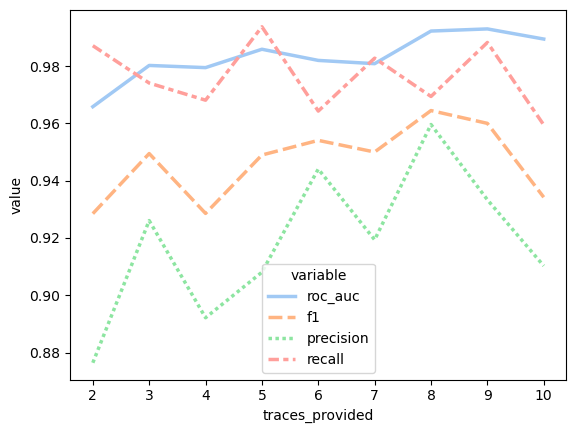

In [211]:
sns.lineplot(data=pd.melt(authentication_results, ['traces_provided']), x='traces_provided', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [29]:
adversary_detection_predictor = TabularPredictor.load("good_anomaly_detection")
iot_device_classifier_predictor = TabularPredictor.load("good_classification")

In [30]:
authentication_results = pd.DataFrame(columns=['traces_provided', 'roc_auc', 'f1', 'precision', 'recall'])

traces_for_this_run = 8
print(traces_for_this_run)

# prep attempts df with right number of feature columns
authentication_attempts = pd.DataFrame(columns=['label'])
for i in range(traces_for_this_run):
    authentication_attempts[f'attempt_{i}'] = pd.Series([], name=f'attempt_{i}')

print(authentication_attempts)

# auth testing for devices with bad label
for single_bad_device in bad_testing_sorted:
    for i in range(0, len(single_bad_device), traces_for_this_run):
        chunk = single_bad_device.iloc[i:i+traces_for_this_run]
        if len(chunk) == traces_for_this_run:
            # process or print the current chunk
            preds = adversary_detection_predictor.predict(chunk)
            # print(preds)
            new_row = {'label': 'bad'}
            for i, pred in enumerate(preds):
                if pred == 'good':
                    id_prediction = iot_device_classifier_predictor.predict(pd.DataFrame(chunk))
                    if id_prediction.iloc[i] == chunk.iloc[i].loc['label']:
                        new_row[f'attempt_{i}'] = 'match'
                    else:
                        new_row[f'attempt_{i}'] = 'mismatch'
                else:
                    new_row[f'attempt_{i}'] = 'malicious'
            authentication_attempts.loc[len(authentication_attempts)]= new_row

# auth testing for devices with good label
for single_good_device in good_testing_sorted:
    for i in range(0, len(single_good_device), traces_for_this_run):
        chunk = single_good_device.iloc[i:i+traces_for_this_run]
        if len(chunk) == traces_for_this_run:
            preds = adversary_detection_predictor.predict(chunk)
            # print(preds)
            new_row = {'label': 'good'}
            for i, pred in enumerate(preds):
                if pred == 'good':
                    id_prediction = iot_device_classifier_predictor.predict(pd.DataFrame(chunk))
                    if id_prediction.iloc[i] == chunk.iloc[i].loc['label']:
                        new_row[f'attempt_{i}'] = 'match'
                    else:
                        new_row[f'attempt_{i}'] = 'mismatch'
                else:
                    new_row[f'attempt_{i}'] = 'malicious'
            authentication_attempts.loc[len(authentication_attempts)]= new_row

# prep the data to train/test
authentication_attempts = authentication_attempts.sample(frac=1).reset_index(drop=True)
auth_train = authentication_attempts[:int(len(authentication_attempts) * 0.8)]
auth_test = authentication_attempts[int(len(authentication_attempts) * 0.8):]

# train and test
# predictor = TabularPredictor(label='label').fit(auth_train, num_gpus=1, presets='good_quality')
# y_pred = predictor.predict(auth_test)
# y_pred_proba = predictor.predict_proba(auth_test)
# results = predictor.evaluate(auth_test)



# new_results = {'traces_provided':traces_for_this_run, 'roc_auc':results['roc_auc'], 'f1':results['f1'], 'precision':results['precision'], 'recall':results['recall']}
# authentication_results.loc[len(authentication_results)] = (new_results)

8
Empty DataFrame
Columns: [label, attempt_0, attempt_1, attempt_2, attempt_3, attempt_4, attempt_5, attempt_6, attempt_7]
Index: []


/home/zac/miniconda3/envs/ag/lib/python3.10/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [55]:
# predictor = TabularPredictor(label='label').fit(auth_train, num_gpus=1, presets='high_quality', included_model_types='CAT')
predictor = TabularPredictor(label='label', fit_weighted_ensemble=False).fit(auth_train, num_gpus=1, presets='high_quality')
y_pred = predictor.predict(auth_test)
y_pred_proba = predictor.predict_proba(auth_test)
results = predictor.evaluate(auth_test)

No path specified. Models will be saved in: "AutogluonModels/ag-20241031_003436"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #47-Ubuntu SMP PREEMPT_DYNAMIC Fri Sep 27 21:40:26 UTC 2024
CPU Count:          12
Memory Avail:       27.35 GB / 30.82 GB (88.7%)
Disk Space Avail:   135.93 GB / 341.37 GB (39.8%)
Presets specified: ['high_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
DySt

In [57]:
results

{'accuracy': 0.949748743718593,
 'balanced_accuracy': 0.9475552850476769,
 'mcc': 0.9003315202290088,
 'roc_auc': 0.9849868127409211,
 'f1': 0.9541284403669725,
 'precision': 0.9285714285714286,
 'recall': 0.9811320754716981}

In [58]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,CatBoost_r137_BAG_L2,0.972222,accuracy,0.222744,41.214316,0.011697,1.092999,2,False,25
1,WeightedEnsemble_L3,0.972222,accuracy,0.223020,41.234002,0.000276,0.019686,3,False,42
2,CatBoost_r198_BAG_L2,0.972222,accuracy,0.223528,41.773571,0.012481,1.652253,2,False,41
3,CatBoost_r5_BAG_L2,0.972222,accuracy,0.223932,41.266268,0.012884,1.144951,2,False,34
4,CatBoost_r50_BAG_L2,0.970960,accuracy,0.222828,42.370067,0.011781,2.248749,2,False,27
...,...,...,...,...,...,...,...,...,...,...
79,CatBoost_r12_BAG_L1_FULL,NaN,accuracy,NaN,0.007677,NaN,0.007677,1,True,60
80,CatBoost_r128_BAG_L2_FULL,NaN,accuracy,NaN,0.367320,NaN,0.020380,2,True,75
81,CatBoost_r128_BAG_L1_FULL,NaN,accuracy,NaN,0.014987,NaN,0.014987,1,True,54
82,CatBoost_BAG_L2_FULL,NaN,accuracy,NaN,0.360893,NaN,0.013953,2,True,64


In [59]:
predictor.delete_models(models_to_keep="best", dry_run=False)

Deleting model CatBoost_BAG_L1. All files under AutogluonModels/ag-20241031_003436/models/CatBoost_BAG_L1 will be removed.
Deleting model CatBoost_r177_BAG_L1. All files under AutogluonModels/ag-20241031_003436/models/CatBoost_r177_BAG_L1 will be removed.
Deleting model CatBoost_r9_BAG_L1. All files under AutogluonModels/ag-20241031_003436/models/CatBoost_r9_BAG_L1 will be removed.
Deleting model CatBoost_r137_BAG_L1. All files under AutogluonModels/ag-20241031_003436/models/CatBoost_r137_BAG_L1 will be removed.
Deleting model CatBoost_r13_BAG_L1. All files under AutogluonModels/ag-20241031_003436/models/CatBoost_r13_BAG_L1 will be removed.
Deleting model CatBoost_r50_BAG_L1. All files under AutogluonModels/ag-20241031_003436/models/CatBoost_r50_BAG_L1 will be removed.
Deleting model CatBoost_r69_BAG_L1. All files under AutogluonModels/ag-20241031_003436/models/CatBoost_r69_BAG_L1 will be removed.
Deleting model CatBoost_r70_BAG_L1. All files under AutogluonModels/ag-20241031_003436/mo